In [1]:
# cleaner version that produces cluster efficiency hists and save to ROOT files and plots

import ROOT as rt
# import root_numpy as rtnp
import csv
import re
import sys
import collections
import uproot
from collections import OrderedDict
import uproot
import pandas as pd
import os
import scipy
import awkward as ak
import numpy as np
import time
from numba import jit
from matplotlib import pyplot as plt
sys.path.append('/users/lisa.benato/private/analysis_notebooks/SUEPs_FWF_feasibility/lib/')
from histo_utilities import create_TH1D, create_TH2D, std_color_list, create_TGraph, make_ratio_plot
import math
from array import array
import CMS_lumi, tdrstyle
style = tdrstyle.setTDRStyle()
CMS_lumi.writeExtraText = 0

wH = 1
Z_MASS = 91.2


# donotdelete = []
print(sys.version)

ERROR in cling::CIFactory::createCI(): cannot extract standard library include paths!
Invoking:
  LC_ALL=C x86_64-conda-linux-gnu-c++   -DNDEBUG -xc++ -E -v /dev/null 2>&1 | sed -n -e '/^.include/,${' -e '/^ \/.*++/p' -e '}'
Results was:
With exit code 0


Welcome to JupyROOT 6.24/06
3.7.12 | packaged by conda-forge | (default, Oct 26 2021, 06:08:53) 
[GCC 9.4.0]


# load ntuples

In [2]:
%%time


m = '55'
lumi = [ 35.9, 41.5, 59.7 ]
year='MC_Fall18'
masses = ['15','40','55','5']
m = '15'
analyzer = '74'
file = {}
tree = {}

# path = "/mnt/hadoop/store/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/csc/V1p17/"+year+"/v2/v93/normalized/"


# file['4Tau_m15'] = path + 'ggH_HToSSTo4Tau_MH-125_MS-15.root'
# file['4Tau_m40'] = path + 'ggH_HToSSTo4Tau_MH-125_MS-40.root'
# file['4Tau_m55'] = path + 'ggH_HToSSTo4Tau_MH-125_MS-55.root'
version = 'v114'

# path = "/mnt/hadoop/store/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/csc/V1p17/"+year+"/v2/v102/normalized/"
# path = '/storage/cms/store/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/csc/V1p17/MC_Fall18_FullGenParticles/v1/'+version+'/normalized/'
path = '/storage/af/user/christiw/login-1/christiw/LLP/displacedJetMuonAnalyzer/csc/V1p17/MC_Fall18_FullGenParticles/v1/v114/normalized/'
file['4Tau'] = path + 'ggH_HToSSTo4Tau_MH-125.root'

# file['4d'] = path + 'ggH_HToSSTodddd_MH-125.root'



# file['4Tau_m7'] = path + 'ggH_HToSSTo4Tau_MH-125_MS-7.root'
# file['4Tau_m15'] = path + 'ggH_HToSSTo4Tau_MH-125_MS-15.root'
# file['4Tau_m40'] = path + 'ggH_HToSSTo4Tau_MH-125_MS-40.root'
# file['4Tau_m55'] = path + 'ggH_HToSSTo4Tau_MH-125_MS-55.root'

# lumi = '137000'
# for decay in ['4Tau', 'dddd']:
#     for m in [7, 15, 40, 55]:
#         for ct in [100,1000,10000,100000]:
#             file[decay+'_m'+str(m)+'_'+str(ct)] = path + 'ggH_HToSSTo'+decay+'_MH-125_MS-'+str(m)+'_ctau-'+str(ct)+'_TuneCP5_13TeV-powheg-pythia8_'+lumi+'pb_weighted.root'


# file['test']='/storage/cms/store/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/csc/V1p17/MC_Fall18/v2/v119/normalized/ggH_HToSS_SToGammaGamma_ms1p0_pl125_137000pb_weighted.root'
# path = '/storage/af/user/christiw/login-1/christiw/LLP/displacedJetMuonAnalyzer/normalized/'
path = '/storage/af/user/christiw/login-1/christiw/LLP/displacedJetMuonAnalyzer/csc/V1p17/MC_Fall18/v2/v119/normalized/'

# file['ggH_HToSS_STodd_ms3p0_pl500'] = path + 'ggH_HToSS_STodd_ms3p0_pl500_137000pb_weighted.root'
# file['ggH_HToSS_STodd_ms3p0_pl100'] = path + 'ggH_HToSS_STodd_ms3p0_pl500_137000pb_weighted.root'

# file['ggH_HToSS_SToGlueGlue_ms3p0_pl100'] = path + 'ggH_HToSS_SToGlueGlue_ms3p0_pl100_137000pb_weighted.root'
# file['ggH_HToSS_SToGlueGlue_ms3p0_pl500'] = path + 'ggH_HToSS_SToGlueGlue_ms3p0_pl500_137000pb_weighted.root'
# file['ggH_HToSS_SToPi0Pi0_ms0p4_pl10'] = path + 'ggH_HToSS_SToPi0Pi0_ms0p4_pl10_137000pb_weighted.root'
# file['ggH_HToSS_SToPi0Pi0_ms0p4_pl50'] = path + 'ggH_HToSS_SToPi0Pi0_ms0p4_pl50_137000pb_weighted.root'
# file['ggH_HToSS_SToPi0Pi0_ms1p0_pl125'] = path + 'ggH_HToSS_SToPi0Pi0_ms1p0_pl125_137000pb_weighted.root'
# file['ggH_HToSS_SToPi0Pi0_ms1p0_pl25'] = path + 'ggH_HToSS_SToPi0Pi0_ms1p0_pl25_137000pb_weighted.root'

file['ggH_HToSS_SToEE_ms0p4_pl10'] = path + 'ggH_HToSS_SToEE_ms0p4_pl10_137000pb_weighted.root'
file['ggH_HToSS_SToEE_ms0p4_pl50'] = path + 'ggH_HToSS_SToEE_ms0p4_pl50_137000pb_weighted.root'
file['ggH_HToSS_SToEE_ms1p0_pl125'] = path + 'ggH_HToSS_SToEE_ms1p0_pl125_137000pb_weighted.root'
file['ggH_HToSS_SToEE_ms1p0_pl25'] = path + 'ggH_HToSS_SToEE_ms1p0_pl25_137000pb_weighted.root'
file['ggH_HToSS_SToEE_ms2p0_pl250'] = path + 'ggH_HToSS_SToEE_ms2p0_pl250_137000pb_weighted.root'
file['ggH_HToSS_SToEE_ms2p0_pl50'] = path + 'ggH_HToSS_SToEE_ms2p0_pl50_137000pb_weighted.root'
file['ggH_HToSS_SToEE_ms4p0_pl100'] = path + 'ggH_HToSS_SToEE_ms4p0_pl100_137000pb_weighted.root'
file['ggH_HToSS_SToEE_ms4p0_pl500'] = path + 'ggH_HToSS_SToEE_ms4p0_pl500_137000pb_weighted.root'

# file['ggH_HToSS_SToGammaGamma_ms0p4_pl10'] = path + 'ggH_HToSS_SToGammaGamma_ms0p4_pl10_137000pb_weighted.root'
# file['ggH_HToSS_SToGammaGamma_ms0p4_pl50'] = path + 'ggH_HToSS_SToGammaGamma_ms0p4_pl50_137000pb_weighted.root'
# file['ggH_HToSS_SToGammaGamma_ms1p0_pl125'] = path + 'ggH_HToSS_SToGammaGamma_ms1p0_pl125_137000pb_weighted.root'
# file['ggH_HToSS_SToGammaGamma_ms1p0_pl25'] = path + 'ggH_HToSS_SToGammaGamma_ms1p0_pl25_137000pb_weighted.root'
# file['ggH_HToSS_SToGammaGamma_ms2p0_pl250'] = path + 'ggH_HToSS_SToGammaGamma_ms2p0_pl250_137000pb_weighted.root'
# file['ggH_HToSS_SToGammaGamma_ms2p0_pl50'] = path + 'ggH_HToSS_SToGammaGamma_ms2p0_pl50_137000pb_weighted.root'
# file['ggH_HToSS_SToGammaGamma_ms4p0_pl100'] = path + 'ggH_HToSS_SToGammaGamma_ms4p0_pl100_137000pb_weighted.root'
# file['ggH_HToSS_SToGammaGamma_ms4p0_pl500'] = path + 'ggH_HToSS_SToGammaGamma_ms4p0_pl500_137000pb_weighted.root'

file['ggH_HToSS_SToPiPlusPiMinus_ms0p4_pl10'] = path + 'ggH_HToSS_SToPiPlusPiMinus_ms0p4_pl10_137000pb_weighted.root'
file['ggH_HToSS_SToPiPlusPiMinus_ms0p4_pl50'] = path + 'ggH_HToSS_SToPiPlusPiMinus_ms0p4_pl50_137000pb_weighted.root'
file['ggH_HToSS_SToPiPlusPiMinus_ms1p0_pl125'] = path + 'ggH_HToSS_SToPiPlusPiMinus_ms1p0_pl125_137000pb_weighted.root'
file['ggH_HToSS_SToPiPlusPiMinus_ms1p0_pl25'] = path + 'ggH_HToSS_SToPiPlusPiMinus_ms1p0_pl25_137000pb_weighted.root'
file['ggH_HToSS_SToPiPlusPiMinus_ms2p0_pl250'] = path + 'ggH_HToSS_SToPiPlusPiMinus_ms2p0_pl250_137000pb_weighted.root'
file['ggH_HToSS_SToPiPlusPiMinus_ms2p0_pl50'] = path + 'ggH_HToSS_SToPiPlusPiMinus_ms2p0_pl50_137000pb_weighted.root'
file['ggH_HToSS_SToPiPlusPiMinus_ms4p0_pl100'] = path + 'ggH_HToSS_SToPiPlusPiMinus_ms4p0_pl100_137000pb_weighted.root'
file['ggH_HToSS_SToPiPlusPiMinus_ms4p0_pl500'] = path + 'ggH_HToSS_SToPiPlusPiMinus_ms4p0_pl500_137000pb_weighted.root'



file = {}

file['4d'] = '/users/lisa.benato/private/DelphesMDS/CMSSW_9_4_4/src/llp_analyzer/MuonSystem_Tree_large.root'
file['4b'] = '/users/lisa.benato/private/DelphesMDS/CMSSW_9_4_4/src/llp_analyzer/Tree_bb.root'
file['4Tau'] = '/users/lisa.benato/private/DelphesMDS/CMSSW_9_4_4/src/llp_analyzer/Tree_tautau.root'
file['ee'] = '/users/lisa.benato/private/DelphesMDS/CMSSW_9_4_4/src/llp_analyzer/Tree_EE.root'

for k, v in file.items():
    print(k,v)
    tree[k] = uproot.open(v)['MuonSystem']
    #branches = tree[k].keys()
    #for b in branches:
    #    if "ct" in b: 
    #        print(b)
    a = tree[k]["ctau"].array()
    print(len(a))
    print(np.mean(a))

4d /users/lisa.benato/private/DelphesMDS/CMSSW_9_4_4/src/llp_analyzer/MuonSystem_Tree_large.root
340000
23907.276470588236
4b /users/lisa.benato/private/DelphesMDS/CMSSW_9_4_4/src/llp_analyzer/Tree_bb.root
20000
12185.65
4Tau /users/lisa.benato/private/DelphesMDS/CMSSW_9_4_4/src/llp_analyzer/Tree_tautau.root
18000
17353.0
ee /users/lisa.benato/private/DelphesMDS/CMSSW_9_4_4/src/llp_analyzer/Tree_EE.root
2000
0.0
CPU times: user 2.52 s, sys: 62.8 ms, total: 2.58 s
Wall time: 2.58 s


In [3]:
def dPhi(x):
    while np.count_nonzero(x>math.pi)>0:
        x[x>math.pi] = x[x>math.pi]-2*math.pi
    while np.count_nonzero(x<-math.pi)>0:
        x[x<-math.pi] = x[x<-math.pi]+2*math.pi
    return x

# load branches

### Another attempt

In [4]:
import awkward as ak
import numpy as np

# Helper to read branches as Awkward
def arr(T, name):
    return T[name].array(library="ak")

# Helper: wrap Δφ to [-π, π]
def dPhi(x):
    return np.abs((x + np.pi) % (2 * np.pi) - np.pi)

# Configuration
cut_based = True
cut_based_version = 'v4'
nCsc_cut = 130

# Output containers
llp_r = {}
llp_z = {}
llp_e = {}
llp_pz = {}
llp_ez = {}
llp_p = {}
llp_gamma = {}
clusterR = {}
clusterZ = {}
clusterE = {}
clusterPz = {}
clusterEz = {}
clusterP = {}
clusterGamma = {}
clusterSize = {}
llp_emfracP = {}
llp_emfracPz = {}
llp_emfracE = {}
llp_emfracEz = {}
clusterEMFracP = {}
clusterEMFracPz = {}
clusterEMFracE = {}
clusterEMFracEz = {}
nCluster = {}

llp_EMP = {}
llp_EMPz = {}
llp_EME = {}
llp_EMEz = {}

llp_HadP = {}
llp_HadPz = {}
llp_HadE = {}
llp_HadEz = {}

clusterEMP = {}
clusterEMPz = {}
clusterEME = {}
clusterEMEz = {}

clusterHadP = {}
clusterHadPz = {}
clusterHadE = {}
clusterHadEz = {}
evtNum = {}
llp_visFracE = {}
cluster_visFracE = {}
higgsPt_denom = {}
higgsPt_nom = {}
llp_ctau = {}
llp_multiplicity = {}
cluster_multiplicity = {}
weight_nom = {}
weight = {}
clusterme1112 = {}
llp_eta = {}
cluster_llp_eta = {}
clusterEta = {}
re12 = {}
mb1 = {}
rb1 = {}
clusterZPos = {}

cscRechitClusterNStation10 = {}
cscRechitClusterEta = {}
cscRechitClusterAvgStation10 = {}
cut_based_dict = {}  # avoid clashing with cut_based flag above
cscRechitClusterPhi = {}
dphiMet_cluster = {}

time = {}
timeSpread = {}
muonVeto = {}
jetVeto = {}

cluster_llp_time = {}

dphiGenMet_cluster = {}
dphiGenMet_llp = {}
cscRechitCluster_llp_Phi = {}

genMetPhi = {}
genMetPt = {}
met = {}
metPhi = {}

for k, T in tree.items():
    print(k)

    # Example (kept for parity, not used later)
    jetPt = arr(T, 'jetPt')
    jetEta = arr(T, 'jetEta')
    sel_jet = (jetPt > 50) & (np.abs(jetEta) < 2.4)

    ########### SELECTION: EVENTS ############
    gLLP_eta = arr(T, 'gLLP_eta')
    gLLP_r = np.abs(arr(T, 'gLLP_decay_vertex_r'))
    gLLP_z = np.abs(arr(T, 'gLLP_decay_vertex_z'))

    sel_llp = (np.abs(gLLP_eta) < 2.4) & (gLLP_r < 695.5) & (np.abs(gLLP_z) < 1100)
    sel_llp = sel_llp & (np.abs(gLLP_z) > 400)

    sel_ev = ak.sum(sel_llp, axis=1) == 1
    sel_llp_ev = sel_llp[sel_ev]  # per-LLP jagged mask for selected events

    # Per-LLP (jagged -> flatten)
    llp_r[k] = ak.flatten(np.abs(arr(T, 'gLLP_decay_vertex_r')[sel_ev][sel_llp_ev]))
    llp_z[k] = ak.flatten(np.abs(arr(T, 'gLLP_decay_vertex_z')[sel_ev][sel_llp_ev]))
    llp_ctau[k] = ak.flatten(np.abs(arr(T, 'gLLP_ctau')[sel_ev][sel_llp_ev]))
    llp_eta[k] = ak.flatten(np.abs(arr(T, 'gLLP_eta')[sel_ev][sel_llp_ev]))

    # Per-event (flat, do NOT flatten)
    higgsPt_denom[k] = arr(T, 'gHiggsPt')[sel_ev]

    print("here")

    # Visible vs total energy/momentum by sample type
    if ('4Tau' not in k) and ('4d' not in k):
        e = arr(T, 'gLLP_e')[sel_ev][sel_llp_ev]
        pt = arr(T, 'gLLP_pt')[sel_ev][sel_llp_ev]
        eta = arr(T, 'gLLP_eta')[sel_ev][sel_llp_ev]
        llp_e[k] = ak.flatten(e)
        llp_ez[k] = ak.flatten(np.abs(e * np.sinh(eta) / np.cosh(eta)))
        llp_pz[k] = ak.flatten(np.abs(pt * np.sinh(eta)))
        llp_p[k] = ak.flatten(np.abs(pt * np.cosh(eta)))
    else:
        llp_e[k] = ak.flatten(arr(T, 'gLLP_visE')[sel_ev][sel_llp_ev])
        llp_ez[k] = ak.flatten(np.abs(arr(T, 'gLLP_visEz')[sel_ev][sel_llp_ev]))
        llp_p[k] = ak.flatten(np.abs(arr(T, 'gLLP_visP')[sel_ev][sel_llp_ev]))
        llp_pz[k] = ak.flatten(np.abs(arr(T, 'gLLP_visPz')[sel_ev][sel_llp_ev]))
        llp_visFracE[k] = ak.flatten(
            arr(T, 'gLLP_visE')[sel_ev][sel_llp_ev] / arr(T, 'gLLP_e')[sel_ev][sel_llp_ev]
        )

    if ('4d' in k) or ('v2' in k):
        llp_multiplicity[k] = ak.flatten(np.abs(arr(T, 'gLLP_multiplicity')[sel_ev][sel_llp_ev]))

    # Partition EM/Had components depending on sample
    if '4b' in k:
        llp_HadP[k] = llp_p[k]
        llp_HadPz[k] = llp_pz[k]
        llp_HadE[k] = llp_e[k]
        llp_HadEz[k] = llp_ez[k]

        zeros = llp_p[k] * 0.0
        llp_emfracP[k] = zeros
        llp_emfracPz[k] = zeros
        llp_emfracE[k] = zeros
        llp_emfracEz[k] = zeros

        llp_EMP[k] = zeros
        llp_EMPz[k] = zeros
        llp_EME[k] = zeros
        llp_EMEz[k] = zeros
    elif ('GlueGlue' in k) or ('STodd' in k) or ('SToPiPlusPiMinus' in k):
        llp_HadP[k] = llp_p[k]
        llp_HadPz[k] = llp_pz[k]
        llp_HadE[k] = llp_e[k]
        llp_HadEz[k] = llp_ez[k]

        zeros = llp_p[k] * 0.0
        llp_emfracP[k] = zeros
        llp_emfracPz[k] = zeros
        llp_emfracE[k] = zeros
        llp_emfracEz[k] = zeros

        llp_EMP[k] = zeros
        llp_EMPz[k] = zeros
        llp_EME[k] = zeros
        llp_EMEz[k] = zeros

    elif ('SToEE' in k) or ('SToPi0Pi0' in k) or ('Gamma' in k):
        llp_EMP[k] = llp_p[k]
        llp_EMPz[k] = llp_pz[k]
        llp_EME[k] = llp_e[k]
        llp_EMEz[k] = llp_ez[k]

        ones = llp_p[k] * 0.0 + 1.0
        llp_emfracP[k] = llp_EMP[k] * ones
        llp_emfracPz[k] = llp_EMP[k] * ones
        llp_emfracE[k] = llp_EMP[k] * ones
        llp_emfracEz[k] = llp_EMP[k] * ones

        zeros = llp_p[k] * 0.0
        llp_HadP[k] = zeros
        llp_HadPz[k] = zeros
        llp_HadE[k] = zeros
        llp_HadEz[k] = zeros

    else:
        llp_emfracP[k] = ak.flatten(arr(T, 'gLLP_EMFracP')[sel_ev][sel_llp_ev])
        llp_emfracPz[k] = ak.flatten(arr(T, 'gLLP_EMFracPz')[sel_ev][sel_llp_ev])
        llp_emfracE[k] = ak.flatten(arr(T, 'gLLP_EMFracE')[sel_ev][sel_llp_ev])
        llp_emfracEz[k] = ak.flatten(arr(T, 'gLLP_EMFracEz')[sel_ev][sel_llp_ev])

        llp_EMP[k] = llp_emfracP[k] * llp_p[k]
        llp_EMPz[k] = llp_emfracPz[k] * llp_pz[k]
        llp_EME[k] = llp_emfracE[k] * llp_e[k]
        llp_EMEz[k] = llp_emfracEz[k] * llp_ez[k]

        llp_HadP[k] = llp_p[k] - llp_EMP[k]
        llp_HadPz[k] = llp_pz[k] - llp_EMPz[k]
        llp_HadE[k] = llp_e[k] - llp_EME[k]
        llp_HadEz[k] = llp_ez[k] - llp_EMEz[k]

    
    
    # Event metadata (per-event; do NOT flatten)
    evtNum[k] = arr(T, 'evtNum')[sel_ev]
    weight[k] = arr(T, 'weight')[sel_ev]

    ########### SELECTION: CLUSTERS ############
    cluster_index = ''
    pref = f'cscRechitCluster{cluster_index}'

    match_eta = arr(T, f'{pref}_match_gLLP_eta')
    match_r = np.abs(arr(T, f'{pref}_match_gLLP_decay_r'))
    match_z = np.abs(arr(T, f'{pref}_match_gLLP_decay_z'))
    size = arr(T, f'{pref}Size')

    sel_rechitcluster = (np.abs(match_eta) < 2.4)
    sel_rechitcluster = sel_rechitcluster & (match_r < 695.5) & (np.abs(match_z) < 1100)
    sel_rechitcluster = sel_rechitcluster & (np.abs(match_z) > 400)
    sel_rechitcluster = sel_rechitcluster & (size >= nCsc_cut)

    nCluster[k] = ak.sum(sel_rechitcluster, axis=1)[sel_ev]
    sel_ev = sel_ev & (ak.sum(sel_rechitcluster, axis=1) == 1)
    print("nCluster after selections: ",ak.sum(sel_rechitcluster, axis=1)[sel_ev])

    # Per-event after cluster selection (flat; do NOT flatten)
    higgsPt_nom[k] = arr(T, 'gHiggsPt')[sel_ev]
    weight_nom[k] = arr(T, 'weight')[sel_ev]

    # Per-cluster (jagged -> flatten)
    clusterR[k] = ak.flatten(np.abs(arr(T, f'{pref}_match_gLLP_decay_r')[sel_rechitcluster][sel_ev]))
    clusterZ[k] = ak.flatten(np.abs(arr(T, f'{pref}_match_gLLP_decay_z')[sel_rechitcluster][sel_ev]))
    clusterZPos[k] = ak.flatten(np.abs(arr(T, f'{pref}Z')[sel_rechitcluster][sel_ev]))

    beta_flat = ak.flatten(arr(T, f'{pref}_match_gLLP_beta')[sel_rechitcluster][sel_ev])
    cluster_llp_time[k] = np.sqrt(clusterR[k] ** 2 + clusterZ[k] ** 2) * (1.0 / np.abs(beta_flat) - 1.0) / 30.0

    cluster_llp_eta[k] = ak.flatten(np.abs(arr(T, f'{pref}_match_gLLP_eta')[sel_rechitcluster][sel_ev]))
    clusterEta[k] = ak.flatten(np.abs(arr(T, f'{pref}Eta')[sel_rechitcluster][sel_ev]))
    clusterSize[k] = ak.flatten(arr(T, f'{pref}Size')[sel_rechitcluster][sel_ev])

    clusterme1112[k] = ak.flatten(
        (
            arr(T, f'{pref}NRechitChamberPlus11')
            + arr(T, f'{pref}NRechitChamberPlus12')
            + arr(T, f'{pref}NRechitChamberMinus11')
            + arr(T, f'{pref}NRechitChamberMinus12')
        )[sel_rechitcluster][sel_ev]
    )

    re12[k] = ak.flatten(arr(T, f'{pref}_match_RE12_0p4')[sel_rechitcluster][sel_ev])
    mb1[k] = ak.flatten(arr(T, f'{pref}_match_MB1Seg_0p4')[sel_rechitcluster][sel_ev])
    rb1[k] = ak.flatten(arr(T, f'{pref}_match_RB1_0p4')[sel_rechitcluster][sel_ev])

    time[k] = ak.flatten(arr(T, f'{pref}TimeTotal')[sel_rechitcluster][sel_ev])
    timeSpread[k] = ak.flatten(arr(T, f'{pref}TimeSpread')[sel_rechitcluster][sel_ev])
    muonVeto[k] = ak.flatten(arr(T, f'{pref}MuonVetoPt')[sel_rechitcluster][sel_ev])
    jetVeto[k] = ak.flatten(arr(T, f'{pref}JetVetoPt')[sel_rechitcluster][sel_ev])

    # Cluster kinematics (depend on sample)
    if ('4Tau' not in k) and ('4d' not in k):
        print(k, " : not usig visible energy but all the LLP energy")
        E = arr(T, f'{pref}_match_gLLP_e')[sel_rechitcluster][sel_ev]
        pt = arr(T, f'{pref}_match_gLLP_pt')[sel_rechitcluster][sel_ev]
        eta_match = arr(T, f'{pref}_match_gLLP_eta')[sel_rechitcluster][sel_ev]
        clusterE[k] = ak.flatten(E)
        clusterPz[k] = ak.flatten(np.abs(pt * np.sinh(eta_match)))
        clusterP[k] = ak.flatten(np.abs(pt * np.cosh(eta_match)))
        clusterEz[k] = ak.flatten(np.abs(E * np.sinh(eta_match) / np.cosh(eta_match)))
    else:
        clusterE[k] = ak.flatten(arr(T, f'{pref}_match_gLLP_visE')[sel_rechitcluster][sel_ev])
        clusterPz[k] = ak.flatten(np.abs(arr(T, f'{pref}_match_gLLP_visPz')[sel_rechitcluster][sel_ev]))
        clusterP[k] = ak.flatten(np.abs(arr(T, f'{pref}_match_gLLP_visP')[sel_rechitcluster][sel_ev]))
        clusterEz[k] = ak.flatten(np.abs(arr(T, f'{pref}_match_gLLP_visEz')[sel_rechitcluster][sel_ev]))
        cluster_visFracE[k] = ak.flatten(
            arr(T, f'{pref}_match_gLLP_visE')[sel_rechitcluster][sel_ev]
            / arr(T, f'{pref}_match_gLLP_e')[sel_rechitcluster][sel_ev]
        )

    if ('4d' in k) or ('v2' in k):
        cluster_multiplicity[k] = ak.flatten(
            np.abs(arr(T, f'{pref}_match_gLLP_multiplicity')[sel_rechitcluster][sel_ev])
        )

    # EM/Had partition for clusters by sample
    if '4b' in k:
        zeros = clusterP[k] * 0.0
        clusterEMFracP[k] = zeros
        clusterEMFracPz[k] = zeros
        clusterEMFracE[k] = zeros
        clusterEMFracEz[k] = zeros

        clusterEMP[k] = zeros
        clusterEMPz[k] = zeros
        clusterEME[k] = zeros
        clusterEMEz[k] = zeros

        clusterHadP[k] = clusterP[k]
        clusterHadPz[k] = clusterPz[k]
        clusterHadE[k] = clusterE[k]
        clusterHadEz[k] = clusterEz[k]

    elif ('SToEE' in k) or ('SToPi0Pi0' in k) or ('Gamma' in k) or ('ee' in k):
        ones = clusterP[k] * 0.0 + 1.0
        clusterEMFracP[k] = clusterP[k] * ones
        clusterEMFracPz[k] = clusterP[k] * ones
        clusterEMFracE[k] = clusterP[k] * ones
        clusterEMFracEz[k] = clusterP[k] * ones

        clusterEMP[k] = clusterP[k]
        clusterEMPz[k] = clusterPz[k]
        clusterEME[k] = clusterE[k]
        clusterEMEz[k] = clusterEz[k]

        zeros = clusterP[k] * 0.0
        clusterHadP[k] = zeros
        clusterHadPz[k] = zeros
        clusterHadE[k] = zeros
        clusterHadEz[k] = zeros

    elif ('GlueGlue' in k) or ('STodd' in k) or ('SToPiPlusPiMinus' in k):
        zeros = clusterP[k] * 0.0
        clusterEMFracP[k] = zeros
        clusterEMFracPz[k] = zeros
        clusterEMFracE[k] = zeros
        clusterEMFracEz[k] = zeros

        clusterEMP[k] = zeros
        clusterEMPz[k] = zeros
        clusterEME[k] = zeros
        clusterEMEz[k] = zeros

        clusterHadP[k] = clusterP[k]
        clusterHadPz[k] = clusterPz[k]
        clusterHadE[k] = clusterE[k]
        clusterHadEz[k] = clusterEz[k]

    else:
        print(k, ": using actual em e frac associated to LLP")
        clusterEMFracP[k] = ak.flatten(np.abs(arr(T, f'{pref}_match_gLLP_EMFracP')[sel_rechitcluster][sel_ev]))
        clusterEMFracPz[k] = ak.flatten(np.abs(arr(T, f'{pref}_match_gLLP_EMFracPz')[sel_rechitcluster][sel_ev]))
        clusterEMFracE[k] = ak.flatten(np.abs(arr(T, f'{pref}_match_gLLP_EMFracE')[sel_rechitcluster][sel_ev]))
        clusterEMFracEz[k] = ak.flatten(np.abs(arr(T, f'{pref}_match_gLLP_EMFracEz')[sel_rechitcluster][sel_ev]))

        clusterEMP[k] = clusterEMFracP[k] * clusterP[k]
        clusterEMPz[k] = clusterEMFracPz[k] * clusterPz[k]
        clusterEME[k] = clusterEMFracE[k] * clusterE[k]
        clusterEMEz[k] = clusterEMFracEz[k] * clusterEz[k]

        clusterHadP[k] = clusterP[k] - clusterEMP[k]
        clusterHadPz[k] = clusterPz[k] - clusterEMPz[k]
        clusterHadE[k] = clusterE[k] - clusterEME[k]
        clusterHadEz[k] = clusterEz[k] - clusterEMEz[k]

    # Other cluster/global quantities
    cscRechitClusterNStation10[k] = ak.flatten(arr(T, f'{pref}NStation10')[sel_rechitcluster][sel_ev])
    cscRechitClusterEta[k] = ak.flatten(arr(T, f'{pref}Eta')[sel_rechitcluster][sel_ev])
    cscRechitClusterAvgStation10[k] = ak.flatten(arr(T, f'{pref}AvgStation10')[sel_rechitcluster][sel_ev])
    cscRechitClusterPhi[k] = ak.flatten(arr(T, f'{pref}Phi')[sel_rechitcluster][sel_ev])
    cscRechitCluster_llp_Phi[k] = ak.flatten(arr(T, f'{pref}_match_gLLP_phi')[sel_rechitcluster][sel_ev])

    # Per-event (flat; do NOT flatten)
    genMetPt[k] = arr(T, 'genMetPtTrue')[sel_ev]
    genMetPhi[k] = arr(T, 'genMetPhiTrue')[sel_ev]
    met[k] = arr(T, 'met')[sel_ev]
    metPhi[k] = arr(T, 'metPhi')[sel_ev]

    # Cut-based definition using cluster-level selections (cluster arrays are flat now)
    avg10 = cscRechitClusterAvgStation10[k]
    eta_abs = np.abs(cscRechitClusterEta[k])

    cond2 = (np.abs(avg10) == 2) & (eta_abs < 1.6)
    cond3 = (np.abs(avg10) == 3) & (eta_abs < 1.6)
    cond4 = (np.abs(avg10) == 4) & (eta_abs < 1.8)
    cond1 = (cscRechitClusterNStation10[k] == 1) & ((np.abs(avg10) == 1) | cond2 | cond3 | cond4)
    cond2b = (cscRechitClusterNStation10[k] > 1) & (eta_abs < 1.9)

    cut_based_dict[k] = cond1 | cond2b | cond3 | cond4

    # Δφ values (cluster arrays are 1D; genMetPhi is per-event for selected events -> same length)
    dphiGenMet_cluster[k] = dPhi(np.abs(cscRechitClusterPhi[k] - genMetPhi[k]))
    dphiGenMet_llp[k] = dPhi(np.abs(cscRechitCluster_llp_Phi[k] - genMetPhi[k]))
    dphiMet_cluster[k] = ak.flatten(np.abs(arr(T, f'{pref}Met_dPhi')[sel_rechitcluster][sel_ev]))

4d
here
nCluster after selections:  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ... 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
4d : using actual em e frac associated to LLP
4b
here
nCluster after selections:  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ... 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
4b  : not usig visible energy but all the LLP energy
4Tau
here
nCluster after selections:  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ... 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
4Tau : using actual em e frac associated to LLP
ee
here
nCluster after selections:  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ... 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
ee  : not usig visible energy but all the LLP energy


# Cluster Efficiency vs. Different Variables (Fig. 78-79 in AN-19-154)

4d [147, 354, 137, 253, 231] [56.6, 79.6, 26, 71.8, 47.9] [90.9, 275, 111, 181, 183]
4b [227, 491, 236, 295, 299] [0, 0, 0, 0, 0] [227, 491, 236, 295, 299]
4Tau [157, 161, 257, 204, 158] [0, 0, 0, 0, 0] [157, 161, 257, 204, 158]
ee [183, 80.7, 83.3, 97.7, 202] [183, 80.7, 83.3, 97.7, 202] [0, 0, 0, 0, 0]


/groups/hephy/cms/lisa.benato/anaconda3/envs/run3/lib/python3.7/site-packages/root_numpy/_hist.py:76: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  ROOT.AsCObject(hist), array, weights, return_indices)
/groups/hephy/cms/lisa.benato/anaconda3/envs/run3/lib/python3.7/site-packages/root_numpy/_hist.py:76: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` 

4d
4d
{'4d': <Array [147, 354, 137, 208, ... 229, 236, 300] type='9567 * float32'>, '4b': <Array [227, 299, 384, ... 96.4, 159, 1.52e+03] type='544 * float32'>, '4Tau': <Array [254, 339, 118, 188, ... 243, 125, 222] type='154 * float32'>, 'ee': <Array [80.7, 202, 92, 118, ... 158, 253, 131] type='93 * float32'>}
[147, 354, 137, 208, 354, 224, 167, 358, ... 397, 435, 174, 532, 346, 229, 236, 300]
4b
4b
{'4d': <Array [147, 354, 137, 208, ... 229, 236, 300] type='9567 * float32'>, '4b': <Array [227, 299, 384, ... 96.4, 159, 1.52e+03] type='544 * float32'>, '4Tau': <Array [254, 339, 118, 188, ... 243, 125, 222] type='154 * float32'>, 'ee': <Array [80.7, 202, 92, 118, ... 158, 253, 131] type='93 * float32'>}
[227, 299, 384, 413, 211, 246, 264, ... 70.8, 80.3, 66.6, 86.4, 96.4, 159, 1.52e+03]
4Tau
4Tau
{'4d': <Array [147, 354, 137, 208, ... 229, 236, 300] type='9567 * float32'>, '4b': <Array [227, 299, 384, ... 96.4, 159, 1.52e+03] type='544 * float32'>, '4Tau': <Array [254, 339, 118, 188, .

/groups/hephy/cms/lisa.benato/anaconda3/envs/run3/lib/python3.7/site-packages/root_numpy/_hist.py:76: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  ROOT.AsCObject(hist), array, weights, return_indices)
/groups/hephy/cms/lisa.benato/anaconda3/envs/run3/lib/python3.7/site-packages/root_numpy/_hist.py:76: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` 

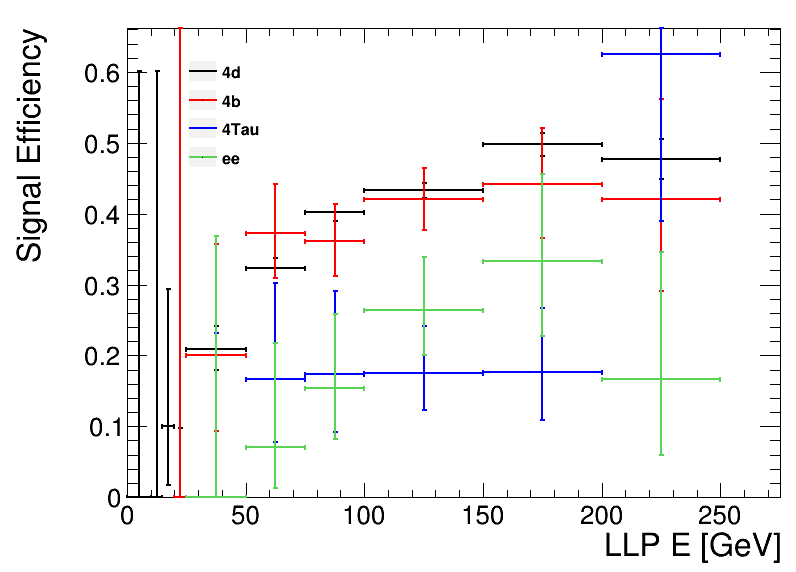

In [5]:
import numpy.ma as ma
import ROOT as rt
import root_numpy
# import importlib
# importlib.reload(sys.modules['histo_utilities'])
# from histo_utilities import std_color_list


for m in llp_e.keys():
    print (m, llp_e[m][0:5], llp_EME[m][0:5], llp_HadE[m][0:5])

numerator = [clusterR,clusterZ,clusterE,clusterPz,clusterEz,clusterGamma, clusterP, clusterEMFracP, clusterEMFracPz, clusterEMFracE, clusterEMFracEz,\
            clusterEMP,clusterEMPz, clusterEME, clusterEMEz,clusterHadP,clusterHadPz,clusterHadE,clusterHadEz,cluster_visFracE, higgsPt_nom, cluster_multiplicity]
denominator = [llp_r,llp_z,llp_e,llp_pz,llp_ez,llp_gamma,llp_p, llp_emfracP, llp_emfracPz, llp_emfracE, llp_emfracEz,\
              llp_EMP,llp_EMPz,llp_EME,llp_EMEz,llp_HadP,llp_HadPz,llp_HadE,llp_HadEz,llp_visFracE, higgsPt_denom,llp_multiplicity]
# bins = [[20,100,700], [35, 550, 1075],  [50,0,500], [50,0,500],[50,0,500],[50,0,100],[50,0,500]]
bins = [[20,100,700], [70, -1275, 1275],  [25,0,500], [25,0,500],[25,0,500],[25,0,100],[25,0,500],[25,0,1], [25,0,1], [25,0,1], [25,0,1],\
       [25,0,500], [25,0,500], [25,0,500], [25,0,500],[25,0,500], [25,0,500], [25,0,500], [25,0,500],[50,0,1]]
bins = [[60,0,700], [70, 400, 1275], [0, 25,50,75,100,150,200,250], [25,0,500],[25,0,500],[25,0,100],[0, 25,50,75,100,150,200,250],[25,0,1], [25,0,1], [100,0,1], [25,0,1],\
       [25,0,500], [25,0,500], [0,25,50,75,100,125,150, 200], [25,0,500],[25,0,500], [25,0,500], [25,0,500], [25,0,500],[20,0,1],[50,0,2000],[100,0,100]]

bins = [[60,0,700], [70, 400, 1275], [0, 25,50,75,100, 150,200,250], [25,0,500],[25,0,500],[25,0,100],[0, 25,50,75,100,150,200,250],[25,0,1], [25,0,1], [100,0,1], [25,0,1],\
       [25,0,500], [25,0,500], [0,25,50,75,100,125,150, 200], [25,0,500],[25,0,500], [25,0,500], [0,25,50,75,100,150,200,250], [25,0,500],[20,0,1],[50,0,2000],[100,0,100]]


bins = [[60,0,700], [70, 400, 1275], [0, 25,50,75,100, 150,250], [25,0,500],[25,0,500],[25,0,100],[0, 25,50,75,100,150,200,250],[25,0,1], [25,0,1], [100,0,1], [25,0,1],\
       [25,0,500], [25,0,500], [0,25,50,75,100,125,150, 200], [25,0,500],[25,0,500], [25,0,500], [0,25,50,75,100,150,200,250], [25,0,500],[20,0,1],[50,0,2000],[100,0,100]]


xaxis = ['LLP decay R [cm]','LLP decay Z [cm]','LLP E [GeV]','LLP p_{Z} [GeV]','LLP Ez [GeV]','LLP #gamma','LLP p [GeV]','EM P fraction', \
         'EM Pz fraction', 'EM E fraction', 'EM Ez fraction','EM P', 'EM Pz', 'EM E', 'EM Ez','Had P', 'Had Pz', 'Had E', 'Had Ez','visible energy fraction','higgsPt','multiplicity']
assert(len(denominator)==len(numerator)==len(bins)==len(xaxis))
index = 2 #LLP E
#index = 13#LLP EM E
#index = 18#LLP Had E

hm = {}
hb = {}
pEff = {}
c = rt.TCanvas('c','c', 800, 600)
leg = rt.TLegend(0.60,0.15, 0.85,0.35)
leg = rt.TLegend(0.23,0.7,0.43,0.90)
# leg = rt.TLegend(0.7,0.7,0.9,0.9)
leg.SetTextSize(0.03)
leg.SetBorderSize(0)
leg.SetEntrySeparation(0.01)
j = 0
for i, m in enumerate(tree.keys()):
    print(m)
#     
#     if  m == 'HNL':continue
#     if index == 7 and not m == '5':continue
#     if not '15' in m:continue
#     if not 'v2' in m and not 'HNL' in m:continue
#     if not '4Tau_m15_' in m and not 'v2' in m:continue

#     if not '4Tau_m' in m or '10' in m:continue
    #w#if not 'ggH_HToSS_SToPiPlusPiMinus' in m:continue
#     if '10000' in m or '100000' in m or 'dddd' in m:continue
        
#     if not 'm15_10' in m :continue
#     if '10' in m:continue
#     if not m == '4Tau':continue

    print(m)
  

    region = 'b'
    print(numerator[index])
    print(clusterE[m])
    
    if region == 'a':
        cond = np.abs(clusterR[m])>390
        cond_b = np.abs(llp_r[m])>390
        cond = np.logical_and(cond, np.abs(clusterZ[m])<671)
        cond_b = np.logical_and(cond_b, np.abs(llp_z[m])<671)
        bins = [[60,0,700], [70, 400, 1275], [0, 25,50,75,100, 150,250], [25,0,500],[25,0,500],[25,0,100],[0, 25,50,75,100,150,200,250],[25,0,1], [25,0,1], [100,0,1], [25,0,1],\
       [25,0,500], [25,0,500], [0,25,50,75,100,125,150, 200], [25,0,500],[25,0,500], [25,0,500], [0,25,50,75,100,150,200,250], [25,0,500],[20,0,1],[50,0,2000],[100,0,100]]

    elif region == 'b':
        cond = np.abs(clusterZ[m])>671
        cond_b = np.abs(llp_z[m])>671
  
        bins = [[60,0,700], [70, 400, 1275], [0, 25,50,75,100, 150,200,250], [25,0,500],[25,0,500],[25,0,100],[0, 25,50,75,100,150,200,250],[25,0,1], [25,0,1], [100,0,1], [25,0,1],\
       [25,0,500], [25,0,500], [0,25,50,75,100,125,150, 200], [25,0,500],[25,0,500], [25,0,500], [0,25,50,75,100,150,200,250], [25,0,500],[20,0,1],[50,0,2000],[100,0,100]]
    bins = [[60,0,700], [70, 400, 1275], [0,10,15,20,25,50,75,100, 150,200,250], [25,0,500],[25,0,500],[25,0,100],[0, 25,50,75,100,150,200,250],[25,0,1], [25,0,1], [100,0,1], [25,0,1],\
       [25,0,500], [25,0,500], [0,25,50,75,100,125,150, 200], [25,0,500],[25,0,500], [25,0,500], [0,25,50,75,100,150,200,250], [25,0,500],[20,0,1],[50,0,2000],[100,0,100]]

    cond = np.logical_and(cond, np.abs(cluster_llp_eta[m])<2)
    cond_b = np.logical_and(cond_b,np.abs(llp_eta[m])<2)
    
    
    cond= np.logical_and(cond, clusterme1112[m]==0)
    cond= np.logical_and(cond, re12[m]==0)
    cond= np.logical_and(cond, rb1[m]==0)
    cond= np.logical_and(cond, mb1[m]==0)
    cond= np.logical_and(cond, timeSpread[m]<20)
    cond= np.logical_and(cond, muonVeto[m]<20)



    hm[m] = create_TH1D(np.abs(numerator[index][m][cond]), 'l', axis_title = [xaxis[index],'Signal Efficiency'], binning=bins[index])
    hb[m] = create_TH1D(np.abs(denominator[index][m][cond_b]), 'l', axis_title = [xaxis[index],'Signal Efficiency'], binning=bins[index])
    
    pEff[m] = rt.TEfficiency(hm[m],hb[m])
    pEff[m].SetLineColor(std_color_list[j])
    pEff[m].SetLineWidth(2)
    pEff[m].SetMarkerSize(0)
    leg.AddEntry(pEff[m], m)
    pEff[m].Draw('' if j == 0 else 'same')
  

    j+=1

leg.Draw()
c.Draw()


ymax = 0.001
xmax = 0.001
ymin = 10000
xmin = 10000
for m in pEff.keys():
    ymax = max(ymax, pEff[m].GetPaintedGraph().GetHistogram().GetMaximum())
    ymin = min(ymin, pEff[m].GetPaintedGraph().GetHistogram().GetMinimum())
    xmin = min(xmin, pEff[m].GetPaintedGraph().GetHistogram().GetXaxis().GetXmin())
    xmax = max(xmax, pEff[m].GetPaintedGraph().GetHistogram().GetXaxis().GetXmax())
ymin = max(0,ymin)

#w#pEff[list(pEff.keys())[0]].GetPaintedGraph().GetHistogram().SetMaximum(ymax)
#w#pEff[list(pEff.keys())[0]].GetPaintedGraph().GetHistogram().SetMinimum(ymin)
#w#pEff[list(pEff.keys())[0]].GetPaintedGraph().GetHistogram().GetXaxis().SetRangeUser(xmin,xmax)

### pEff[list(pEff.keys())[0]].GetPaintedGraph().GetHistogram().SetBins(10,0.,10.)


### leg.Draw()

#w#pEff[list(pEff.keys())[0]].GetPaintedGraph().GetHistogram().SetMinimum(0.0)




# Cluster Efficiency Plot (Additional Figure 7)

### produce plot pdf

/groups/hephy/cms/lisa.benato/anaconda3/envs/run3/lib/python3.7/site-packages/root_numpy/_hist.py:71: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  ROOT.AsCObject(hist), array, weights, return_indices)
/groups/hephy/cms/lisa.benato/anaconda3/envs/run3/lib/python3.7/site-packages/root_numpy/_hist.py:71: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` 

200 75
200 100
200 150


200 75
200 100
200 150




/groups/hephy/cms/lisa.benato/anaconda3/envs/run3/lib/python3.7/site-packages/root_numpy/_hist.py:71: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  ROOT.AsCObject(hist), array, weights, return_indices)
/groups/hephy/cms/lisa.benato/anaconda3/envs/run3/lib/python3.7/site-packages/root_numpy/_hist.py:71: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` 

200 75
200 100
200 150


200 75
200 100
200 150




Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: hb1 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: hb1 (Potential memory leak).
Info in <TCanvas::Print>: png file /users/lisa.benato/private/DelphesMDS/CMSSW_9_4_4/src/llp_analyzer/4d_regionAnRechits130_correction_pas.png has been created
Info in <TCanvas::Print>: pdf file /users/lisa.benato/private/DelphesMDS/CMSSW_9_4_4/src/llp_analyzer/4d_regionAnRechits130_correction_pas.pdf has been created
Info in <TCanvas::SaveSource>: C++ Macro file: /users/lisa.benato/private/DelphesMDS/CMSSW_9_4_4/src/llp_analyzer/4d_regionAnRechits130_correction_pas.C has been generated
Warning in <TROOT::Append>: Replacing existing TH1: hb1 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: hb1 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: hb1 (Potential memory leak).
Warning in <TROOT::Append>: Replac

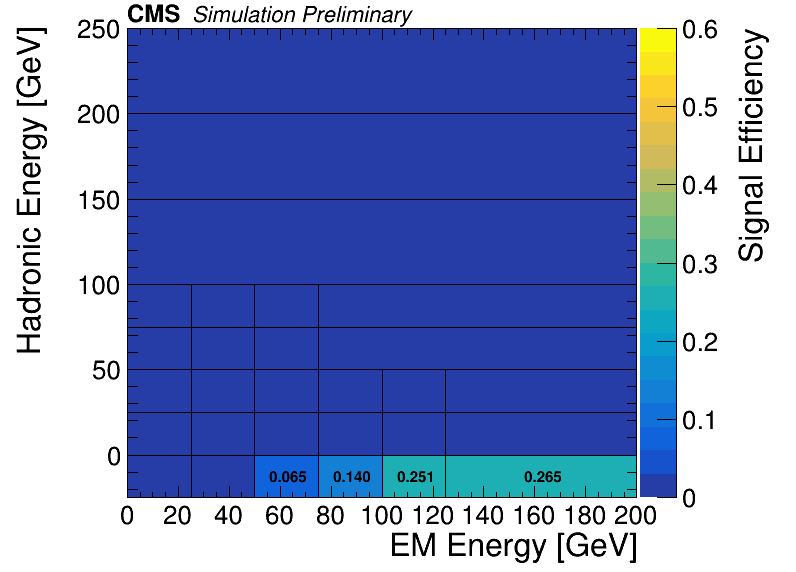

In [6]:

correction = 0.90898
rt.gStyle.SetPaintTextFormat("6.3f")
numerator = [ clusterEME,clusterHadE]
denominator = [llp_EME,llp_HadE]

bins = {'a':[[0, 25,50,100,200], [0, 0,25,50,75,100, 150, 250]], 'b':[[0,25,50,75,100,125, 200],  [0,0,25,50,75,100,150,200,250]]}

bins_plot = {'a':[[0, 25,50,100,200], [-25, 0,25,50,75,100, 150, 250]],'b':[ [0,25,50,75,100,125, 200],  [-25,0,25,50,75,100,150,200,250]]}

xaxis = [ 'EM Energy [GeV]', 'Hadronic Energy [GeV]']

assert(len(denominator)==len(numerator)==len(bins)==len(xaxis))
index = [0,1]
hm = {}
hb = {}
pEff = {}
eff_hist = {}
eff_histUp = {}
eff_histDown = {}
h2p = {}
h2pUp = {}
h2pDown = {}



def to_np_pair(x, y):
    # x, y are Awkward 1D after your selections/masks
    # Optional: drop Nones if present
    if ak.any(ak.is_none(x)) or ak.any(ak.is_none(y)):
        x = ak.drop_none(x)
        y = ak.drop_none(y)
    xa = ak.to_numpy(x)
    ya = ak.to_numpy(y)
    # Flatten if needed
    xa = xa.reshape(-1)
    ya = ya.reshape(-1)
    return np.column_stack((xa, ya))


nCsc_cut = 130
for i,m in enumerate(tree.keys()):
    #w#if not m == '4Tau':continue

    c = rt.TCanvas('c','c', 800, 600)

    

    for region in ['a','b']:
#         if not region == 'b':continue

        bins_temp = bins[region][index[0]]+bins[region][index[1]]+[len(bins[region][index[0]])]+[len(bins[region][index[1]])]
        bins_plot_temp = bins_plot[region][index[0]]+bins_plot[region][index[1]]+[len(bins_plot[region][index[0]])]+[len(bins_plot[region][index[1]])]
        key = m+'_'+region+'_'+str(nCsc_cut)
        if region == 'a':
            condm = np.abs(clusterR[m])>390
            condb = np.abs(llp_r[m])>390
            condm = np.logical_and(condm, np.abs(clusterZ[m])<671)
            condb = np.logical_and(condb, np.abs(llp_z[m])<671)
        elif region == 'b':
            condm = np.abs(clusterZ[m])>671
            condb = np.abs(llp_z[m])>671

        condm = np.logical_and(condm, np.abs(cluster_llp_eta[m])<2)
        condb = np.logical_and(condb,np.abs(llp_eta[m])<2)

        condm= np.logical_and(condm, clusterme1112[m]==0)
        condm= np.logical_and(condm, re12[m]==0)
        condm= np.logical_and(condm, rb1[m]==0)
        condm= np.logical_and(condm, mb1[m]==0)
        condm= np.logical_and(condm, timeSpread[m]<20)
        condm= np.logical_and(condm, muonVeto[m]<20)
        condm= np.logical_and(condm, clusterSize[m]>=nCsc_cut)

        
        

        a_num0 = numerator[index[0]][m][condm]
        a_num1 = numerator[index[1]][m][condm]
        sample_hm = to_np_pair(a_num0, a_num1)

        b_den0 = denominator[index[0]][m][condb]
        b_den1 = denominator[index[1]][m][condb]
        sample_hb = to_np_pair(b_den0, b_den1)

        sample_eff = to_np_pair(a_num0, a_num1)  # numerator again for eff_hist

        hm[key] = create_TH2D(
            sample_hm, 'hb1',
            axis_title=[xaxis[index[0]], xaxis[index[1]], 'Signal Efficiency'],
            binning=bins_temp
        )

        hb[key] = create_TH2D(
            sample_hb, 'hb1',
            axis_title=[xaxis[index[0]], xaxis[index[1]], 'Signal Efficiency'],
            binning=bins_temp
        )

        eff_hist[key] = create_TH2D(
            sample_eff, 'hb1',
            axis_title=[xaxis[index[0]], xaxis[index[1]], 'Signal Efficiency'],
            binning=bins_plot_temp
        )
        eff_histUp[key] = eff_hist[key].Clone()
        eff_histDown[key] = eff_hist[key].Clone()
        
        

        #print(m,index[0],denominator[index[0]].keys())
        #print(m,index[0],denominator[index[1]][m])
        #print("www")
        #a = ak.to_numpy(nominator[index[0]][m][condm])
        #b = ak.to_numpy(nominator[index[1]][m][condm])
        #sample_hm = np.column_stack((a, b))

        #a = ak.to_numpy(denominator[index[0]][m][condb])
        #b = ak.to_numpy(denominator[index[1]][m][condb])
        #sample_hb = np.column_stack((a, b))

        #hm[key] = create_TH2D(sample_hm, 'hb1',
        #              axis_title=[xaxis[index[0]], xaxis[index[1]], 'Signal Efficiency'],
        #              binning=bins_temp)

        #hb[key] = create_TH2D(sample_hb, 'hb1',
        #              axis_title=[xaxis[index[0]], xaxis[index[1]], 'Signal Efficiency'],
        #              binning=bins_temp)
        
        
        #hm[key] = create_TH2D(np.column_stack((nominator[index[0]][m][condm],nominator[index[1]][m][condm])), 'hb1',\
        #                         axis_title = [xaxis[index[0]],xaxis[index[1]],'Signal Efficiency'], binning=bins_temp)
        #hb[key] = create_TH2D(np.column_stack((denominator[index[0]][m][condb],denominator[index[1]][m][condb])), 'hb1', axis_title = [xaxis[index[0]],xaxis[index[1]],'Signal Efficiency'], \
        #                      binning=bins_temp)

        #eff_hist[key] = create_TH2D(np.column_stack((nominator[index[0]][m][condm],nominator[index[1]][m][condm])), 'hb1',\
        #                         axis_title = [xaxis[index[0]],xaxis[index[1]],'Signal Efficiency'], binning=bins_plot_temp)
        #eff_histUp[key] = eff_hist[key].Clone()
        #eff_histDown[key] = eff_hist[key].Clone()
        
        pEff[key] = rt.TEfficiency(hm[key],hb[key])
        pEff[key].SetLineWidth(2)
        
        if region == 'a':
            for y in range(1, eff_hist[key].GetYaxis().GetNbins()+1):
                if y>=5:
                    n1 = 0
                    n2 = 0
                    for x in range(1, eff_hist[key].GetXaxis().GetNbins()+1):
                        n1 += hm[key].GetBinContent(x,y)
                        n2 += hb[key].GetBinContent(x,y)
                for x in range(1, eff_hist[key].GetXaxis().GetNbins()+1):
                    ratio = 0
                    errLow = 0
                    errHigh = 0

                    if y < 5:
                        n1 = hm[key].GetBinContent(x,y)
                        n2 = hb[key].GetBinContent(x,y)
                    if n1 > n2: n1 = n2
                    if n2>0:
                        ratio = 1.0 * n1/n2
                        if ratio > 1: ratio = 1
                        errLow = ratio - rt.TEfficiency.ClopperPearson(n2, n1, 0.68269, False);
                        errHigh = rt.TEfficiency.ClopperPearson(n2, n1, 0.68269, True) - ratio
                    eff_histUp[key].SetBinContent(x,y,errHigh*correction)
                    eff_histDown[key].SetBinContent(x,y,errLow*correction)
                    eff_hist[key].SetBinContent(x,y,ratio*correction)
                    
        else:
            for y in range(1, eff_hist[key].GetYaxis().GetNbins()+1):
                n1 = 0
                n2 = 0
                if y>=6:
                    for x in range(1, eff_hist[key].GetXaxis().GetNbins()+1):
                        n1 += hm[key].GetBinContent(x,y)
                        n2 += hb[key].GetBinContent(x,y)

                for x in range(1, eff_hist[key].GetXaxis().GetNbins()+1):
                    ratio = 0
                    errLow = 0
                    errHigh = 0

                    if (y < 6 and x <= 3) or y <=3:
                        n1 = hm[key].GetBinContent(x,y)
                        n2 = hb[key].GetBinContent(x,y)
                    elif y>=4 and y < 6:
                        n1 = hm[key].GetBinContent(4,y) + hm[key].GetBinContent(5,y) + hm[key].GetBinContent(6,y)
                        n2 = hb[key].GetBinContent(4,y) + hb[key].GetBinContent(5,y) + hb[key].GetBinContent(6,y)
#                         print(x,y)
#                     else:
#                         print(x,y,n1,n2)
                    if n1 > n2: n1 = n2
                    if n2>0:
                        ratio = 1.0 * n1/n2
                        if ratio > 1: ratio = 1
                        errLow = ratio - rt.TEfficiency.ClopperPearson(n2, n1, 0.68269, False);
                        errHigh = rt.TEfficiency.ClopperPearson(n2, n1, 0.68269, True) - ratio
                    eff_histUp[key].SetBinContent(x,y,errHigh*correction)
                    eff_histDown[key].SetBinContent(x,y,errLow*correction)
                    eff_hist[key].SetBinContent(x,y,ratio*correction)

        h2p[key] = rt.TH2Poly()
        h2pUp[key] = rt.TH2Poly()
        h2pDown[key] = rt.TH2Poly()

        if region == 'a':
            for i_y, y in enumerate(bins_plot[region][1]):
                if i_y == len(bins_plot[region][1])-1:continue
                if i_y > 3:
                    print(x,y)
                    h2p[key].AddBin(bins_plot[region][0][0], y, bins_plot[region][0][-1], bins_plot[region][1][i_y+1])
                    h2pUp[key].AddBin(bins_plot[region][0][0], y, bins_plot[region][0][-1], bins_plot[region][1][i_y+1])
                    h2pDown[key].AddBin(bins_plot[region][0][0], y, bins_plot[region][0][-1], bins_plot[region][1][i_y+1])
                    binNum = h2p[key].FindBin((bins_plot[region][0][0]+bins_plot[region][0][-1])/2, (y+bins_plot[region][1][i_y+1])/2)
                    h2p[key].SetBinContent(binNum, eff_hist[key].GetBinContent(1, i_y+1))
                    h2pUp[key].SetBinContent(binNum, eff_histUp[key].GetBinContent(1, i_y+1))
                    h2pDown[key].SetBinContent(binNum, eff_histDown[key].GetBinContent(1, i_y+1))

                else:
                    for i_x, x in enumerate(bins_plot[region][0]):
                        if i_x == len(bins_plot[region][0])-1:continue


                        h2p[key].AddBin(x, y, bins_plot[region][0][i_x+1], bins_plot[region][1][i_y+1])
                        h2pUp[key].AddBin(x, y, bins_plot[region][0][i_x+1], bins_plot[region][1][i_y+1])
                        h2pDown[key].AddBin(x, y, bins_plot[region][0][i_x+1], bins_plot[region][1][i_y+1])
#                         if eff_hist[key].GetBinContent(i_x+1, i_y+1)<=0.0:continue


                        binNum = h2p[key].FindBin((x+ bins_plot[region][0][i_x+1])/2, (y+bins_plot[region][1][i_y+1])/2)
                        h2p[key].SetBinContent(binNum, eff_hist[key].GetBinContent(i_x+1, i_y+1))
                        h2pUp[key].SetBinContent(binNum, eff_histUp[key].GetBinContent(i_x+1, i_y+1))
                        h2pDown[key].SetBinContent(binNum, eff_histDown[key].GetBinContent(i_x+1, i_y+1))
        else:
            for i_y, y in enumerate(bins_plot[region][1]):
                if i_y == len(bins_plot[region][1])-1:continue
                if i_y > 4:
                    h2p[key].AddBin(bins_plot[region][0][0], y, bins_plot[region][0][-1], bins_plot[region][1][i_y+1])
                    h2pUp[key].AddBin(bins_plot[region][0][0], y, bins_plot[region][0][-1], bins_plot[region][1][i_y+1])
                    h2pDown[key].AddBin(bins_plot[region][0][0], y, bins_plot[region][0][-1], bins_plot[region][1][i_y+1])
                    binNum = h2p[key].FindBin((bins_plot[region][0][0]+bins_plot[region][0][-1])/2, (y+bins_plot[region][1][i_y+1])/2)
                    h2p[key].SetBinContent(binNum, eff_hist[key].GetBinContent(1, i_y+1))
                    h2pUp[key].SetBinContent(binNum, eff_histUp[key].GetBinContent(1, i_y+1))
                    h2pDown[key].SetBinContent(binNum, eff_histDown[key].GetBinContent(1, i_y+1))
                else:
                    for i_x, x in enumerate(bins_plot[region][0]):
                        if i_x == len(bins_plot[region][0])-1:continue
                        if i_y > 2 and i_x >=3:
                            if i_x>3:continue
                            h2p[key].AddBin(x, y, bins_plot[region][0][-1], bins_plot[region][1][i_y+1])
                            h2pUp[key].AddBin(x, y, bins_plot[region][0][-1], bins_plot[region][1][i_y+1])
                            h2pDown[key].AddBin(x, y, bins_plot[region][0][-1], bins_plot[region][1][i_y+1])
                            binNum = h2p[key].FindBin((x+ bins_plot[region][0][-1])/2, (y+bins_plot[region][1][i_y+1])/2)
                            h2p[key].SetBinContent(binNum, eff_hist[key].GetBinContent(i_x+1, i_y+1))
                            h2pUp[key].SetBinContent(binNum, eff_hist[key].GetBinContent(i_x+1, i_y+1))
                            h2pDown[key].SetBinContent(binNum, eff_hist[key].GetBinContent(i_x+1, i_y+1))
                        else:
#                             if eff_hist[key].GetBinContent(i_x+1, i_y+1)<=0.0:continue


                            h2p[key].AddBin(x, y, bins_plot[region][0][i_x+1], bins_plot[region][1][i_y+1])
                            h2pUp[key].AddBin(x, y, bins_plot[region][0][i_x+1], bins_plot[region][1][i_y+1])
                            h2pDown[key].AddBin(x, y, bins_plot[region][0][i_x+1], bins_plot[region][1][i_y+1])
                            binNum = h2p[key].FindBin((x+ bins_plot[region][0][i_x+1])/2, (y+bins_plot[region][1][i_y+1])/2)
                            h2p[key].SetBinContent(binNum, eff_hist[key].GetBinContent(i_x+1, i_y+1))
                            h2pUp[key].SetBinContent(binNum, eff_histUp[key].GetBinContent(i_x+1, i_y+1))
                            h2pDown[key].SetBinContent(binNum, eff_histDown[key].GetBinContent(i_x+1, i_y+1))
                            

        for b in  h2p[key].GetBins():
            b.GetPolygon().SetLineWidth(0)

        if region == 'b':h2p[key].SetMaximum(0.6)
        else:h2p[key].SetMaximum(0.2)
        h2p[key].SetMinimum(0.0)
        h2p[key].SetMarkerSize(1.4)
        h2p[key].GetXaxis().SetTitle(xaxis[0])
        h2p[key].GetYaxis().SetTitle(xaxis[1])
        h2p[key].GetZaxis().SetTitle('Signal Efficiency')
        h2p[key].Draw('colz text ')
        
        c.SetRightMargin(0.2)
        
        CMS_lumi.cmsText     = "CMS"
        CMS_lumi.writeExtraText = 1
        CMS_lumi.extraText   = "Simulation Supplementary"
        CMS_lumi.extraText   = "Simulation Preliminary"
        CMS_lumi.relPosX = 0.12
        CMS_lumi.CMS_lumi(c, 0, 0)
    
        c.Draw()
        outDir = '/storage/af/user/christiw/gpu/christiw/llp/delayed_jet_analyzer/plots/MuonSystem_Analysis/supplementary/cluster_eff/'+version+'/'
        outDir = "/users/lisa.benato/private/DelphesMDS/CMSSW_9_4_4/src/llp_analyzer/"
        #if not os.path.isdir(outDir): os.makedirs(outDir)
        file_name = outDir+m+'_region'+region.capitalize()+'nRechits'+str(nCsc_cut)
        
        if correction <1:file_name += '_correction'
        if CMS_lumi.writeExtraText and CMS_lumi.extraText == 'Simulation Preliminary': file_name += "_pas"
        if CMS_lumi.writeExtraText and CMS_lumi.extraText == 'Simulation Supplementary': file_name += "_supplementary"
            
        c.SaveAs(file_name + '.png')
        c.SaveAs(file_name + '.pdf')
        c.SaveAs(file_name + '.C')






### save to ROOT file

In [7]:

outputFileName = '/users/lisa.benato/private/DelphesMDS/CMSSW_9_4_4/src/llp_analyzer/cluster_eff_'+str(nCsc_cut)+'_correction.root'
print(outputFileName)

outFile = rt.TFile(outputFileName, 'UPDATE')
for m in eff_hist.keys():
    print(m)
    #if not '4Tau' in m:continue
    if not '4d' in m:continue
    outFile.WriteTObject(eff_hist[m], 'h_'+m, 'WriteDelete')
    outFile.WriteTObject(eff_histUp[m], 'h_'+m+'Up', 'WriteDelete')
    outFile.WriteTObject(eff_histDown[m], 'h_'+m+'Down', 'WriteDelete')
    outFile.WriteTObject(h2p[m], 'h_poly_'+m, 'WriteDelete')
    outFile.WriteTObject(h2pUp[m], 'h_poly_'+m+'Up', 'WriteDelete')
    outFile.WriteTObject(h2pDown[m], 'h_poly_'+m+'Down', 'WriteDelete')
outFile.Close();

/users/lisa.benato/private/DelphesMDS/CMSSW_9_4_4/src/llp_analyzer/cluster_eff_130_correction.root
4d_a_130
4d_b_130
4b_a_130
4b_b_130
4Tau_a_130
4Tau_b_130
ee_a_130
ee_b_130


### create Y slice (show uncertainty)

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file /users/lisa.benato/private/DelphesMDS/CMSSW_9_4_4/src/llp_analyzer/4Tau_a_130nRechits130_bin1.png has been created
Info in <TCanvas::Print>: pdf file /users/lisa.benato/private/DelphesMDS/CMSSW_9_4_4/src/llp_analyzer/4Tau_a_130nRechits130_bin1.pdf has been created
Info in <TCanvas::SaveSource>: C++ Macro file: /users/lisa.benato/private/DelphesMDS/CMSSW_9_4_4/src/llp_analyzer/4Tau_a_130nRechits130_bin1.C has been generated
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file /users/lisa.benato/private/DelphesMDS/CMSSW_9_4_4/src/llp_analyzer/4Tau_a_130nRechits130_bin2.png has been created
Info in <TCanvas::Print>: pdf file /users/lisa.benato/private/DelphesMDS/CMSSW_9_4_4/src/llp_analyzer/4Tau_a_130nRechits130_bin2.pdf has been created
Info in <TCanvas::SaveSource>: C++ Macro file: /users/lisa.benato/private/DelphesMDS/CMSSW_9_4_4/src

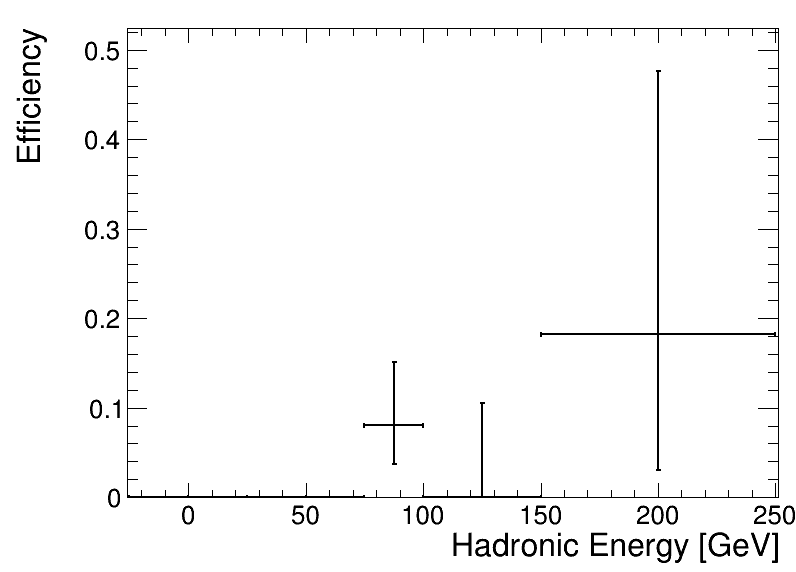

In [8]:
key = '4Tau_a_130'


for b in range(1, eff_hist[key].GetNbinsX()+1):
    canvas = rt.TCanvas('c','c', 800, 600)
    nbins = eff_hist[key].GetNbinsY()
    x = []
    y = []
    xErrLow = []
    xErrHigh = []
    yErrLow = []
    yErrHigh = []

    for c in range(nbins):
        x.append(eff_hist[key].GetYaxis().GetBinCenter(c+1))
        xErrLow.append(eff_hist[key].GetYaxis().GetBinCenter(c+1) - eff_hist[key].GetYaxis().GetBinLowEdge(c+1)) 
        xErrHigh.append(eff_hist[key].GetYaxis().GetBinUpEdge(c+1) - eff_hist[key].GetYaxis().GetBinCenter(c+1))

        y.append(eff_hist[key].GetBinContent(b,c+1))
        yErrLow.append(eff_histDown[key].GetBinContent(b,c+1))
        yErrHigh.append(eff_histUp[key].GetBinContent(b,c+1))






    efficiency = rt.TGraphAsymmErrors(nbins, array("d", x), array("d", y), array("d", xErrLow), array("d", xErrHigh),array("d", yErrLow) ,array("d", yErrHigh) )
    efficiency.GetYaxis().SetTitle('Efficiency')

    efficiency.GetXaxis().SetTitle('Hadronic Energy [GeV]')
    efficiency.SetLineWidth(2)
    efficiency.Draw('AP')
    canvas.Draw()


    # efficiency.GetHistogram().SetMaximum(1.0)
    efficiency.GetHistogram().SetMinimum(0.0)
    efficiency.GetHistogram().GetXaxis().SetRangeUser(-25,250)
    canvas.SetRightMargin(0.022)

    canvas.Draw()

    
    outDir = '/users/lisa.benato/private/DelphesMDS/CMSSW_9_4_4/src/llp_analyzer/'
    if not os.path.isdir(outDir): os.makedirs(outDir)    
    file_name = outDir+key+'nRechits'+str(nCsc_cut)+'_bin'+str(b)

    canvas.SaveAs(file_name + '.png')
    canvas.SaveAs(file_name + '.pdf')
    canvas.SaveAs(file_name + '.C')






## ratio of 2D efficiency

In [9]:

rt.gStyle.SetPaintTextFormat("6.3f");


for nom in h2p.keys():
    for denom in h2p.keys():
        
        if not (nom == '4Tau_b_130' and denom == '4Tau_b_50') :continue
        print(nom, denom)
#         for region in ['a', 'b', 'c']:
        if not region == 'b':continue
        c = rt.TCanvas('c','c', 800, 600)
        ratio = h2p[nom].Clone()
        ratio.Divide(h2p[denom])
        ratio.GetZaxis().SetTitle('Ratio')
        ratio.SetMaximum(2)
        ratio.SetMinimum(0.0)
        ratio.SetMarkerSize(1.0)
        ratio.Draw('colz text')
        c.SetRightMargin(0.2)
        # c.SetBottomMargin(0.2)


        c.Draw()
#             outDir = '/storage/user/christiw/gpu/christiw/llp/delayed_jet_analyzer/plots/MuonSystem_Analysis/supplementary/ratio/'
#             c.SaveAs(outDir+nom+'_'+denom+'_ratio_region'+region.capitalize()+'nRechits'+str(nCsc_cut)+'.png')
#             c.SaveAs(outDir+nom+'_'+denom+'_ratio_region'+region.capitalize()+'nRechits'+str(nCsc_cut)+'.C')

#             c.SaveAs(outDir+nom+'_'+denom+'_ratio_region'+region.capitalize()+'nRechits'+str(nCsc_cut)+'.pdf')


### check accuracy of signal yield prediction using parameterization vs full-sim preduction (Table 53/54 in AN-19-154)

In [10]:
print(version)

v114


In [14]:
import numpy as np
import awkward as ak
import uproot

# Helper: convert Awkward/NumPy inputs to 1D NumPy arrays
def to_np_1d(a):
    if isinstance(a, ak.Array):
        a = ak.to_numpy(a)
    return np.asarray(a).reshape(-1)

# use the denominator of different samples, find the efficiency in 2D
nCsc_cut = 130
useJetVeto = False
if useJetVeto:
    source_file1 = uproot.open('/storage/af/user/christiw/gpu/christiw/llp/delayed_jet_analyzer/plots/MuonSystem_Analysis/supplementary/' + version + '/cluster_eff_' + str(nCsc_cut) + '_withJetVeto.root')
else:
    source_file1 = uproot.open('/users/lisa.benato/private/DelphesMDS/CMSSW_9_4_4/src/llp_analyzer/cluster_eff_' + str(nCsc_cut) + '_correction.root')

wt = {}
observed = {}
wt_err = {}
observed_err = {}
print(tree.keys())

# initialize accumulators for the sources of interest
#for k in ['4Tau']:
for k in ['4d']:
    for m in tree.keys():
        wt[k + '_' + m] = 0.0
        observed[k + '_' + m] = 0.0
        wt_err[k + '_' + m] = 0.0
        observed_err[k + '_' + m] = 0.0

for region in ['a', 'b', 'c']:
    if region != 'b':
        continue
    #for source in ['4Tau']:
    for source in ['4d']:
        eff_hist = source_file1[f'h_{source}_{region}_{nCsc_cut}']  # uproot Model_TH2D_v4

        # Pre-extract numpy lookup arrays from the histogram
        ret = eff_hist.to_numpy()
        # For TH2, uproot returns (values, xedges, yedges)
        if len(ret) == 3:
            vals, xedges, yedges = ret
        else:
            # Fallback (shouldn't happen for TH2), try to unpack as (values, (xedges, yedges))
            vals, edges = ret
            xedges, yedges = edges

        # Ensure values array is oriented as (nx, ny)
        nx, ny = len(xedges) - 1, len(yedges) - 1
        if vals.shape == (ny, nx):
            vals = vals.T
        elif vals.shape != (nx, ny):
            # As a last resort, try squeezing; then recheck and possibly transpose
            vals = np.squeeze(vals)
            if vals.shape == (ny, nx):
                vals = vals.T
            elif vals.shape != (nx, ny):
                raise RuntimeError(f"Unexpected values shape {vals.shape} for edges (nx, ny)=({nx}, {ny})")

        for m in tree.keys():
            # Prepare x,y inputs for lookup
            xvals = to_np_1d(llp_EME[m])                 # EM energy
            yvals = to_np_1d(np.abs(llp_HadE[m]))        # |Had energy|

            # Compute bin indices with searchsorted
            ix = np.searchsorted(xedges, xvals, side="right") - 1  # 0-based x-bin
            iy = np.searchsorted(yedges, yvals, side="right") - 1  # 0-based y-bin

            # Special-case: y == 0 in first y-bin
            iy[yvals == 0.0] = 0

            # Clip indices to valid bin range (ignore under/overflow)
            ix = np.clip(ix, 0, nx - 1)
            iy = np.clip(iy, 0, ny - 1)

            weight = vals[ix, iy]  # 1D array of weights for events in sample m
            print(weight)

            # Build masks for numerator/denominator selections (convert to NumPy 1D arrays)
            clusterR_m        = to_np_1d(clusterR[m])
            clusterZ_m        = to_np_1d(clusterZ[m])
            cluster_llp_eta_m = to_np_1d(cluster_llp_eta[m])
            clusterme1112_m   = to_np_1d(clusterme1112[m])
            re12_m            = to_np_1d(re12[m])
            rb1_m            = to_np_1d(rb1[m])
            mb1_m            = to_np_1d(mb1[m])
            timeSpread_m      = to_np_1d(timeSpread[m])
            muonVeto_m        = to_np_1d(muonVeto[m])
            jetVeto_m         = to_np_1d(jetVeto[m]) if useJetVeto else None
            clusterSize_m     = to_np_1d(clusterSize[m])

            llp_r_m           = to_np_1d(llp_r[m])
            llp_z_m           = to_np_1d(llp_z[m])
            llp_eta_m         = to_np_1d(llp_eta[m])

            if region == 'a':
                condm = (np.abs(clusterR_m) > 390)
                condb = (np.abs(llp_r_m) > 390)
                condm &= (np.abs(clusterZ_m) < 671)
                condb &= (np.abs(llp_z_m) < 671)
            elif region == 'b':
                condm = (np.abs(clusterZ_m) > 671)
                condb = (np.abs(llp_z_m) > 671)
            else:
                # Define region 'c' if needed; currently unused
                condm = np.ones_like(clusterR_m, dtype=bool)
                condb = np.ones_like(llp_r_m, dtype=bool)

            condm &= (np.abs(cluster_llp_eta_m) < 2)
            condb &= (np.abs(llp_eta_m) < 2)

            condm &= (clusterme1112_m == 0)
            condm &= (re12_m == 0)
            condm &= (rb1_m == 0)
            condm &= (mb1_m == 0)
            condm &= (timeSpread_m < 20)
            condm &= (muonVeto_m < 20)
            condm &= (clusterSize_m >= nCsc_cut)
            if useJetVeto:
                condm &= (jetVeto_m < 10)

            # Accumulate yields and uncertainties
            wt[f'{source}_{m}']           += np.sum(weight[condb])                  # parameterized prediction
            observed[f'{source}_{m}']     += np.count_nonzero(condm)                # observed events
            wt_err[f'{source}_{m}']       += np.sqrt(np.sum(weight[condb]**2))      # quadrature sum
            observed_err[f'{source}_{m}'] += np.sqrt(np.count_nonzero(condm))       # Poisson

dict_keys(['4d', '4b', '4Tau', 'ee'])
[0.46777918 0.44092313 0.44669874 ... 0.45346406 0.44092313 0.44092313]
[0.44092313 0.44092313 0.44092313 ... 0.33638776 0.44092313 0.44092313]
[0.45346406 0.45346406 0.44092313 0.44092313 0.45346406 0.45346406
 0.44092313 0.45346406 0.44092313 0.44092313 0.44092313 0.44669874
 0.44092313 0.45346406 0.45346406 0.45346406 0.44669874 0.45346406
 0.45346406 0.44669874 0.45346406 0.44092313 0.44669874 0.45346406
 0.44669874 0.44092313 0.4213198  0.44092313 0.44092313 0.45346406
 0.44092313 0.44092313 0.44092313 0.44092313 0.45346406 0.44092313
 0.45346406 0.44669874 0.44092313 0.44669874 0.45346406 0.44092313
 0.44092313 0.45346406 0.45346406 0.44092313 0.44092313 0.45346406
 0.44092313 0.44092313 0.45346406 0.44092313 0.44092313 0.44092313
 0.33638776 0.44092313 0.44669874 0.44092313 0.44669874 0.44669874
 0.44669874 0.44092313 0.44092313 0.44092313 0.45346406 0.44092313
 0.44092313 0.44092313 0.44669874 0.45346406 0.44092313 0.45346406
 0.44092313 0.

### print ratio between parameterized and full-simulation signal yield

In [15]:
correction = 0.90898
#for source in ['4Tau']:
for source in ['4d']:
    for target in tree.keys():
        n1 = wt[source+'_'+target]
        n2 = correction*observed[source+'_'+target]
        if n2 == 0:continue
        ratio = 1.0*n1/n2
        err = ((wt_err[source+'_'+target]/n1)**2+(correction*observed_err[source+'_'+target]/n2)**2)**0.5*ratio
        print(target, '\t', 'obs: ', round(n2,2), '\t pred: ', round(n1,2) , '\t ratio: ', round(ratio,3), '+/-', round(err,3))


4d 	 obs:  2624.23 	 pred:  2625.42 	 ratio:  1.0 +/- 0.022
4b 	 obs:  149.98 	 pred:  175.65 	 ratio:  1.171 +/- 0.108
4Tau 	 obs:  29.09 	 pred:  68.24 	 ratio:  2.346 +/- 0.455
ee 	 obs:  28.18 	 pred:  0.0 	 ratio:  0.0 +/- nan


/groups/hephy/cms/lisa.benato/anaconda3/envs/run3/lib/python3.7/site-packages/ipykernel_launcher.py:9: RuntimeWarning: invalid value encountered in double_scalars
  if __name__ == "__main__":


# calculate fraction of events in each region

In [13]:
events = {}
for m in tree.keys():
    events[m] = 0.0
    for region in ['a','b','c']:
        key = m+'_'+region
        if region == 'a':
            condm = np.abs(clusterR[m])>390
            condb = np.abs(llp_r[m])>390
            condm = np.logical_and(condm, np.abs(clusterZ[m])<671)
            condb = np.logical_and(condb, np.abs(llp_z[m])<671)
        elif region == 'b':
            condm = np.abs(clusterZ[m])>671
            condb = np.abs(llp_z[m])>671
        elif region == 'c':
            condm = np.abs(clusterR[m])<270
            condb = np.abs(llp_r[m])<270
            condm = np.logical_and(condm, np.abs(clusterZ[m])<671)
            condb = np.logical_and(condb, np.abs(llp_z[m])<671)

        condm = np.logical_and(condm, np.abs(cluster_llp_eta[m])<2)
        condb = np.logical_and(condb,np.abs(llp_eta[m])<2)


        condm= np.logical_and(condm, clusterme1112[m]==0)
        condm= np.logical_and(condm, re12[m]==0)
        condm= np.logical_and(condm, rb1[m]==0)
        condm= np.logical_and(condm, mb1[m]==0)
        condm= np.logical_and(condm, timeSpread[m]<20)
        condm= np.logical_and(condm, muonVeto[m]<20)
        events[m] += np.count_nonzero(condm)
        
for m in tree.keys():
    for region in ['a','b','c']:
#         if not region == 
        key = m+'_'+region
        if region == 'a':
            condm = np.abs(clusterR[m])>390
            condb = np.abs(llp_r[m])>390
            condm = np.logical_and(condm, np.abs(clusterZ[m])<671)
            condb = np.logical_and(condb, np.abs(llp_z[m])<671)
        elif region == 'b':
            condm = np.abs(clusterZ[m])>671
            condb = np.abs(llp_z[m])>671
        elif region == 'c':
            condm = np.abs(clusterR[m])<270
            condb = np.abs(llp_r[m])<270
            condm = np.logical_and(condm, np.abs(clusterZ[m])<671)
            condb = np.logical_and(condb, np.abs(llp_z[m])<671)

        condm = np.logical_and(condm, np.abs(cluster_llp_eta[m])<2)
        condb = np.logical_and(condb,np.abs(llp_eta[m])<2)


        condm= np.logical_and(condm, clusterme1112[m]==0)
        condm= np.logical_and(condm, re12[m]==0)
        condm= np.logical_and(condm, rb1[m]==0)
        condm= np.logical_and(condm, mb1[m]==0)
        condm= np.logical_and(condm, timeSpread[m]<20)
        condm= np.logical_and(condm, muonVeto[m]<20)
        
        
        print(key, '\t', np.count_nonzero(condm)/events[m])

4d_a 	 0.0738727214582667
4d_b 	 0.9232491205628398
4d_c 	 0.002878157978893508
4b_a 	 0.08839779005524862
4b_b 	 0.9116022099447514
4b_c 	 0.0
4Tau_a 	 0.13513513513513514
4Tau_b 	 0.8648648648648649
4Tau_c 	 0.0
ee_a 	 0.24390243902439024
ee_b 	 0.7560975609756098
ee_c 	 0.0
